# 🧼 RepoHunter Data Cleaning Lab
This notebook is used to interactively clean and standardize the synthesized training pairs before fine-tuning.

In [1]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt

input_file = '../database/training/matchmaker_pairs.jsonl'
output_file = '../database/training/platinum_matchmaker.jsonl'

# Load data
data = []
with open(input_file, 'r') as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)
print(f"📊 Loaded {len(df)} initial pairs.")
df.head()

📊 Loaded 346 initial pairs.


,text
0,### Instruction: I'm trying to build a secure ...
1,### Instruction: We're looking to build an ent...
2,### Instruction: I'm looking for a way to anal...
3,### Instruction: I'm looking for a way to auto...
4,### Instruction: I'm a researcher working on a...


## 📈 Dataset Statistics
Let's look at the distribution of text lengths to catch short/incomplete answers.

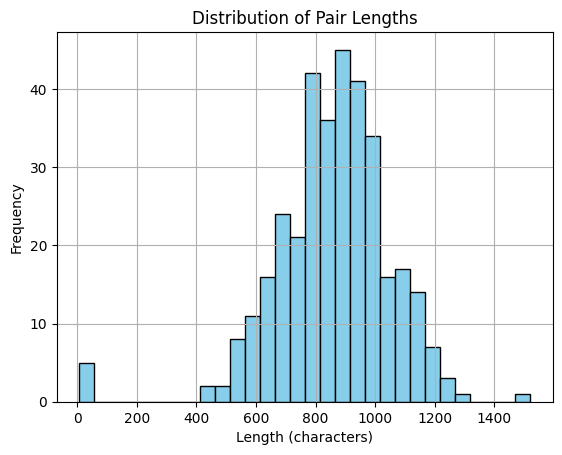

count     346.000000
mean      857.115607
std       194.899405
min         7.000000
25%       761.250000
50%       871.000000
75%       975.000000
max      1521.000000
Name: length, dtype: float64


In [2]:
df['length'] = df['text'].apply(len)
df['length'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Pair Lengths')
plt.xlabel('Length (characters)')
plt.ylabel('Frequency')
plt.show()

print(df['length'].describe())

## 🧹 Cleaning Logic
1. **Deduplication**: Remove exact duplicates.
2. **Filtering**: Remove items shorter than a threshold (e.g., 300 chars).
3. **Refinement**: Strip common AI assistant conversational filler.

In [3]:
# 1. Deduplicate
initial_count = len(df)
df = df.drop_duplicates(subset=['text'])
print(f"🔄 Removed {initial_count - len(df)} duplicate entries.")

# 2. Length Filter
min_length = 300
df = df[df['length'] >= min_length]
print(f"📉 Removed {initial_count - len(df)} total entries including short responses.")

# 3. Strip Junk (Heuristics)
junk_prefixes = ["Certainly!", "Here is", "I recommend", "This repository"]
for prefix in junk_prefixes:
    df['text'] = df['text'].str.replace(f"### Response: {prefix}", "### Response: ", case=False)

print(f"✅ Cleaning complete. {len(df)} High-quality pairs remaining.")

🔄 Removed 4 duplicate entries.
📉 Removed 5 total entries including short responses.
✅ Cleaning complete. 341 High-quality pairs remaining.


## 🚀 Export Platinum Dataset

In [4]:
df[['text']].to_json(output_file, orient='records', lines=True)
print(f"💾 Saved {len(df)} pairs to {output_file}")

💾 Saved 341 pairs to ../database/training/platinum_matchmaker.jsonl
